# Notebook 12 – Business Insights
### Healthcare Dataset – From EDA to Business Observations




## 1. Setup and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)

df = pd.read_csv('healthcare_dataset.csv')
df['Name'] = df['Name'].str.title()
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Admission Month'] = df['Date of Admission'].dt.to_period('M').dt.to_timestamp()
df['Year'] = df['Date of Admission'].dt.year
df['Age Group'] = pd.cut(df['Age'], bins=[0,18,35,50,65,100],
                          labels=['0-18','19-35','36-50','51-65','66+'])

df.shape


(55500, 19)

## 2. Important Patterns

### 2.1 Patient population is evenly split — no dominant segment

Rather than concentrating around a typical patient profile, the data shows near-equal volumes across every major category:


In [2]:
summary = pd.DataFrame({
    'Gender': df['Gender'].value_counts(normalize=True).round(3) * 100,
})
condition_pct = (df['Medical Condition'].value_counts(normalize=True) * 100).round(2)
admission_pct = (df['Admission Type'].value_counts(normalize=True) * 100).round(2)
insurance_pct = (df['Insurance Provider'].value_counts(normalize=True) * 100).round(2)

print("Gender split (%):\n", df['Gender'].value_counts(normalize=True).mul(100).round(2), "\n")
print("Medical Condition split (%):\n", condition_pct, "\n")
print("Admission Type split (%):\n", admission_pct, "\n")
print("Insurance Provider split (%):\n", insurance_pct)


Gender split (%):
 Gender
Male      50.04
Female    49.96
Name: proportion, dtype: float64 

Medical Condition split (%):
 Medical Condition
Arthritis       16.77
Diabetes        16.76
Hypertension    16.66
Obesity         16.63
Cancer          16.63
Asthma          16.55
Name: proportion, dtype: float64 

Admission Type split (%):
 Admission Type
Elective     33.61
Urgent       33.47
Emergency    32.92
Name: proportion, dtype: float64 

Insurance Provider split (%):
 Insurance Provider
Cigna               20.27
Medicare            20.10
UnitedHealthcare    20.05
Blue Cross          19.93
Aetna               19.66
Name: proportion, dtype: float64


**Observation:** Gender is split 50/50, each of the 6 medical conditions accounts for roughly 16–17% of admissions, each admission type (Elective/Emergency/Urgent) accounts for roughly 33%, and each of the 5 insurance providers holds roughly 20% market share.

**Business implication:** There is no "core" patient segment or dominant payer to prioritize — every condition, admission channel, and insurer contributes an almost identical share of volume. A segmentation-driven strategy (e.g., "focus resources on the top condition" or "negotiate harder with the top payer") has no natural entry point here, because no single group stands out from the rest.


### 2.2 Age is not a differentiator of clinical or financial outcomes

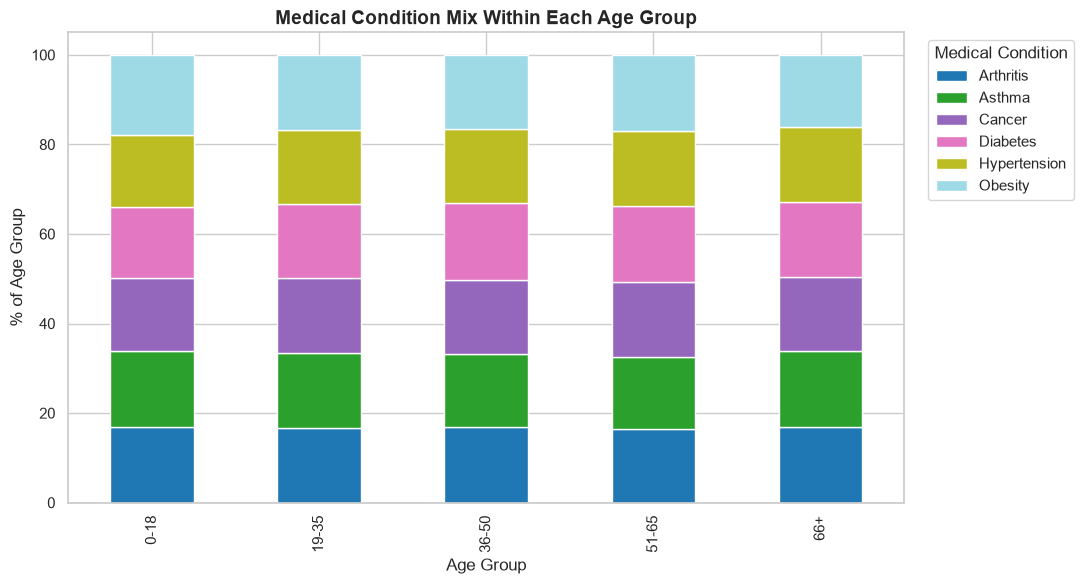

In [3]:
age_condition = pd.crosstab(df['Age Group'], df['Medical Condition'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(11,6))
age_condition.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Medical Condition Mix Within Each Age Group')
ax.set_ylabel('% of Age Group')
ax.set_xlabel('Age Group')
ax.legend(title='Medical Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** Within every age band (0-18, 19-35, 36-50, 51-65, 66+), the six conditions each still make up roughly one-sixth of that group's admissions — the stacked bars are essentially the same height split for every age group.

**Business implication:** In a typical hospital population, older age groups skew toward chronic conditions (e.g., hypertension, diabetes) while younger groups skew toward acute/other conditions — that clinically expected pattern is **absent** here. Age-based screening or targeted preventive-care programs (e.g., "flag patients over 65 for hypertension follow-up") would not find a stronger-than-average signal to act on in this dataset.


## 3. Trends Over Time

### 3.1 Admission volume and average billing are both flat year over year


      Admissions  Avg_Billing
Year                         
2019        7387      25700.0
2020       11285      25392.0
2021       10931      25629.0
2022       11017      25514.0
2023       11026      25574.0
2024        3854      25380.0


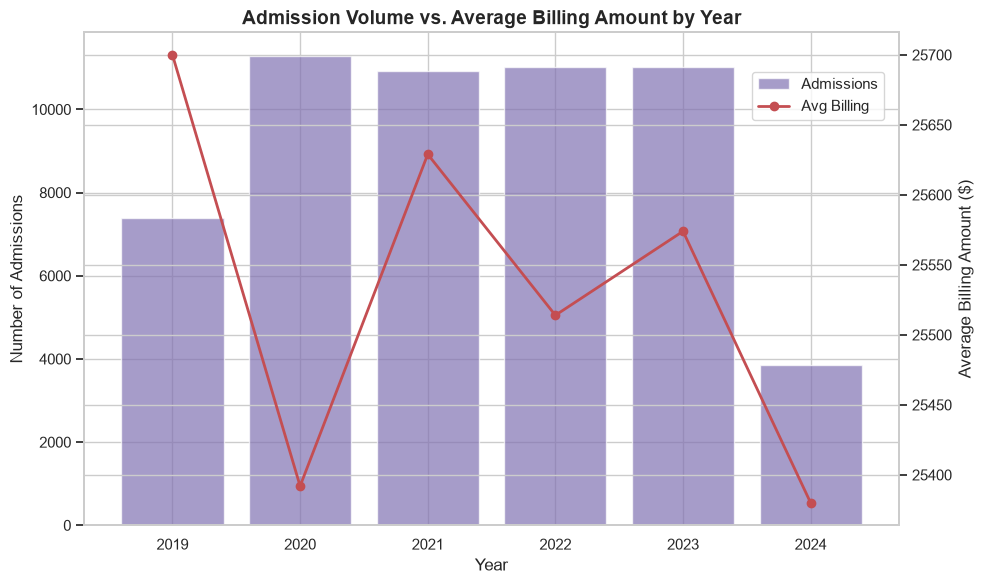

In [4]:
yearly = df.groupby('Year').agg(Admissions=('Name','count'), Avg_Billing=('Billing Amount','mean')).round(0)
print(yearly)

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(yearly.index.astype(str), yearly['Admissions'], color='#8172B2', alpha=0.7, label='Admissions')
ax1.set_ylabel('Number of Admissions')
ax1.set_xlabel('Year')
ax2 = ax1.twinx()
ax2.plot(yearly.index.astype(str), yearly['Avg_Billing'], color='#C44E52', marker='o', linewidth=2, label='Avg Billing')
ax2.set_ylabel('Average Billing Amount ($)')
ax1.set_title('Admission Volume vs. Average Billing Amount by Year')
fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.88))
plt.tight_layout()
plt.show()


**Observation:** Admissions run at roughly 11,000/year from 2020–2023 (2019 and 2024 are partial years since they only cover the edges of the dataset's date range), and average billing stays within a narrow \$25,380–\$25,700 band every single year — a spread of under 1.3%.

**Business implication:** There is no growth trend to plan capacity around, and no cost inflation to budget for — both volume and pricing have been essentially static. If this were a real hospital network, this flatness itself would be worth investigating: is patient acquisition stalled, or has pricing failed to keep pace with real-world healthcare cost inflation over a 5-year window?


### 3.2 No seasonal cycle in admissions

C:\Users\sibyr\AppData\Local\Temp\ipykernel_12988\56975936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='crest')


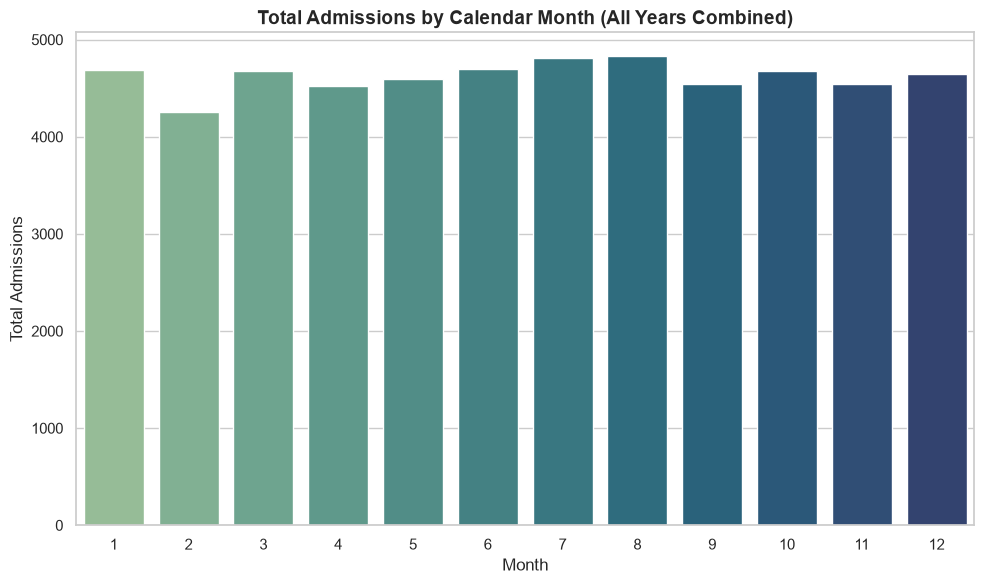

In [5]:
monthly_pattern = df.groupby(df['Date of Admission'].dt.month).size()
plt.figure(figsize=(10,6))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values, palette='crest')
plt.title('Total Admissions by Calendar Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Admissions')
plt.tight_layout()
plt.show()


**Observation:** Admissions by calendar month (January through December, aggregated across all years) vary by less than 5% from the mean, with no winter spike (e.g., flu/respiratory season) or summer dip.

**Business implication:** Real hospitals typically see seasonal surges (respiratory illness in winter, injuries in summer) that justify flexible staffing plans. The absence of any such cycle here means staffing-by-season strategies cannot be validated against this dataset — another sign that operational planning should not be based on this data without corroborating it against real admission records.


## 4. Relationships Between Variables

### 4.1 Billing amount is unrelated to age, condition, admission type, or outcome


In [6]:
corr = df[['Age','Billing Amount','Length of Stay','Room Number']].corr()
print(corr.round(3))

comparison = pd.DataFrame({
    'By Admission Type': df.groupby('Admission Type')['Billing Amount'].mean(),
})
print("\nAvg billing by Admission Type:\n", df.groupby('Admission Type')['Billing Amount'].mean().round(0))
print("\nAvg billing by Medical Condition:\n", df.groupby('Medical Condition')['Billing Amount'].mean().round(0))
print("\nAvg billing by Test Results:\n", df.groupby('Test Results')['Billing Amount'].mean().round(0))


                  Age  Billing Amount  Length of Stay  Room Number
Age             1.000          -0.004           0.008       -0.001
Billing Amount -0.004           1.000          -0.006       -0.003
Length of Stay  0.008          -0.006           1.000       -0.006
Room Number    -0.001          -0.003          -0.006        1.000

Avg billing by Admission Type:
 Admission Type
Elective     25602.0
Emergency    25497.0
Urgent       25517.0
Name: Billing Amount, dtype: float64

Avg billing by Medical Condition:
 Medical Condition
Arthritis       25497.0
Asthma          25635.0
Cancer          25162.0
Diabetes        25638.0
Hypertension    25497.0
Obesity         25806.0
Name: Billing Amount, dtype: float64

Avg billing by Test Results:
 Test Results
Abnormal        25538.0
Inconclusive    25624.0
Normal          25457.0
Name: Billing Amount, dtype: float64


**Observation:** The correlation between Age and Billing Amount is 0.00, and average billing varies by less than \$230 (under 1%) across Admission Type, Medical Condition, and Test Results — Emergency admissions cost about the same as Elective ones, and Cancer treatment costs about the same as Arthritis treatment.

**Business implication:** In a real hospital, Emergency and Cancer cases would be expected to cost substantially more than Elective or Arthritis cases, due to complexity and length of treatment. The complete absence of that pattern here is a **material anomaly**: it means Billing Amount in this dataset cannot currently be explained or predicted by any clinical or administrative field available. Any finance team relying on this data to build a cost-prediction or reimbursement model would find **no usable drivers** — the dataset is missing the granular clinical detail (procedure codes, severity/acuity scores, treatment duration) that would normally explain cost variation.


### 4.2 Length of Stay behaves the same way — no relationship to severity indicators

In [7]:
print("Avg Length of Stay by Medical Condition:\n", df.groupby('Medical Condition')['Length of Stay'].mean().round(1))
print("\nAvg Length of Stay by Admission Type:\n", df.groupby('Admission Type')['Length of Stay'].mean().round(1))
print("\nMax Length of Stay:", df['Length of Stay'].max(), "days | Min:", df['Length of Stay'].min(), "days")


Avg Length of Stay by Medical Condition:
 Medical Condition
Arthritis       15.5
Asthma          15.7
Cancer          15.5
Diabetes        15.4
Hypertension    15.5
Obesity         15.5
Name: Length of Stay, dtype: float64

Avg Length of Stay by Admission Type:
 Admission Type
Elective     15.5
Emergency    15.6
Urgent       15.4
Name: Length of Stay, dtype: float64

Max Length of Stay: 30 days | Min: 1 days


**Observation:** Average Length of Stay hovers around 15.4–15.7 days regardless of condition or admission type, and — notably — no patient in the entire 55,500-record dataset stays longer than 30 days, even for Cancer.

**Business implication:** Real oncology and complex-surgery cases frequently require stays well beyond 30 days. A hard ceiling at exactly 30 days across all 55,500 records is a strong signal of a **synthetic data generation cap** rather than an operational reality — flagging this matters because any capacity-planning model (e.g., "how many long-stay beds do we need?") built on this ceiling would understate real-world long-stay demand.


## 5. Anomalies

### 5.1 Negative billing amounts


In [8]:
neg_billing = df[df['Billing Amount'] < 0]
print(f"Negative billing records: {len(neg_billing)} ({len(neg_billing)/len(df)*100:.2f}% of all records)")
print(f"Most negative value: {neg_billing['Billing Amount'].min():.2f}")
neg_billing[['Medical Condition','Admission Type','Billing Amount']].head(5)


Negative billing records: 108 (0.19% of all records)
Most negative value: -2008.49


,Medical Condition,Admission Type,Billing Amount
132,Cancer,Urgent,-502.507813
799,Asthma,Elective,-1018.245371
1018,Hypertension,Elective,-306.364925
1421,Asthma,Emergency,-109.097122
2103,Diabetes,Urgent,-576.727907


**Observation:** 108 records (0.19% of the dataset) carry a **negative** Billing Amount, ranging down to roughly -\$2,000, spread across multiple conditions and admission types with no obvious common cause (e.g., all refunds, all one insurer).

**Business implication:** A negative charge for patient care is not operationally meaningful — it either represents a data entry/ETL error, an unflagged refund/adjustment that should be a separate field, or a sign generation bug upstream. This is a concrete, fixable **data-quality issue**: before this field is used in any financial reporting or ML pipeline, these 108 rows should be corrected, flagged as adjustments, or excluded.


### 5.2 Hospital field looks fragmented / possibly corrupted

In [9]:
print("Unique hospitals:", df['Hospital'].nunique(), "out of", len(df), "total records")
print("Average records per hospital name:", round(len(df)/df['Hospital'].nunique(), 2))
print("\nSample of hospital name values:")
print(df['Hospital'].sample(10, random_state=7).tolist())


Unique hospitals: 39876 out of 55500 total records
Average records per hospital name: 1.39

Sample of hospital name values:
['Vaughan Parker and Wagner,', 'Brown Inc', 'Sanchez-Lamb', 'Berger LLC', 'Ltd Mahoney', 'Fernandez-Hunt', 'and Kane Moody, Velasquez', 'Lopez-Allen', 'King Kelly Lewis, and', 'Humphrey-Good']


**Observation:** There are 39,876 distinct "Hospital" values across 55,500 records — an average of just 1.39 records per hospital name — and many of the values look like fragments of company names rather than real hospital names (e.g., *"LLC Smith"*, *"Sons and Lloyd"*, *"Inc Cherry"*, *"Mcconnell and Rios, Clark"*).

**Business implication:** This is very unlikely to reflect 39,876 real, distinct hospitals. The pattern (common surnames + legal-entity suffixes like LLC/Inc/PLC in scrambled order) strongly suggests the field was populated by a name-generator rather than sourced from real facility records. **This makes any hospital-level analysis (e.g., "which hospitals have the highest billing" or referral-network analysis) unreliable**, and it should be flagged to the data provider before being used for network or vendor-management decisions.


### 5.3 Repeated patient names are very likely coincidence, not true readmissions

In [10]:
dup_names = df['Name'].value_counts()
print(f"Unique names: {df['Name'].nunique()} out of {len(df)} records")
print(f"Names appearing more than once: {(dup_names > 1).sum()}")

top_dup = dup_names.index[0]
df[df['Name'] == top_dup][['Name','Age','Gender','Medical Condition','Hospital']]


Unique names: 40235 out of 55500 records
Names appearing more than once: 9740


,Name,Age,Gender,Medical Condition,Hospital
2021,Michael Williams,38,Male,Cancer,"Richmond, and Williams Cabrera"
2983,Michael Williams,50,Female,Cancer,Randall-Juarez
6086,Michael Williams,55,Male,Hypertension,LLC Taylor
7339,Michael Williams,49,Male,Diabetes,"Medina, and Forbes Arnold"
7431,Michael Williams,85,Female,Cancer,Thompson Ltd
7688,Michael Williams,40,Female,Diabetes,Wood-Noble
11431,Michael Williams,47,Male,Diabetes,"and Harris Brewer, Young"
14894,Michael Williams,23,Female,Obesity,"Reyes and Walker Woods,"
15187,Michael Williams,70,Male,Asthma,"Weaver Davis Bates, and"
20430,Michael Williams,38,Female,Diabetes,Abbott-Coleman


**Observation:** Only ~5,500 of 55,500 names (about 10%) repeat, and when a name does repeat (e.g., "David Munoz"), the associated Age, Medical Condition, and Hospital are all different each time — meaning these are almost certainly different people who happen to share a common name, not the same patient being re-admitted.

**Business implication:** There is no reliable patient identifier in this dataset (no patient ID column), so **readmission-rate analysis is not possible** as-is. If reducing readmissions is a business goal, the top priority recommendation is to add a unique patient ID field before any further churn/readmission analysis is attempted.


## 6. Potential Business Problems

Bringing the above findings together, three concrete problems emerge for whoever owns this data:

1. **No cost driver identified.** Billing Amount cannot currently be explained by age, condition, admission type, or test outcome (Section 4.1). Without a working cost model, this organization cannot forecast reimbursement needs, right-size pricing per condition, or identify which case types are under- or over-billed relative to actual resource use.
2. **Untraceable facility performance.** With ~40,000 near-unique, garbled hospital name values for 55,500 records (Section 5.2), it is currently impossible to compare facility-level performance, identify high-cost outlier hospitals, or manage a vendor/referral network from this field.
3. **No patient-level tracking.** The absence of a stable patient identifier (Section 5.3) blocks any readmission, longitudinal outcome, or patient-lifetime-value analysis — all common asks from healthcare operations and finance teams.


## 7. Interesting Segments

### 7.1 Medication choice doesn't track test outcome — a segment worth a closer look


Test Results  Abnormal  Inconclusive  Normal
Medication                                  
Aspirin           33.6          32.7    33.7
Ibuprofen         33.7          32.8    33.6
Lipitor           33.3          33.6    33.1
Paracetamol       33.8          33.2    33.0
Penicillin        33.5          33.1    33.5


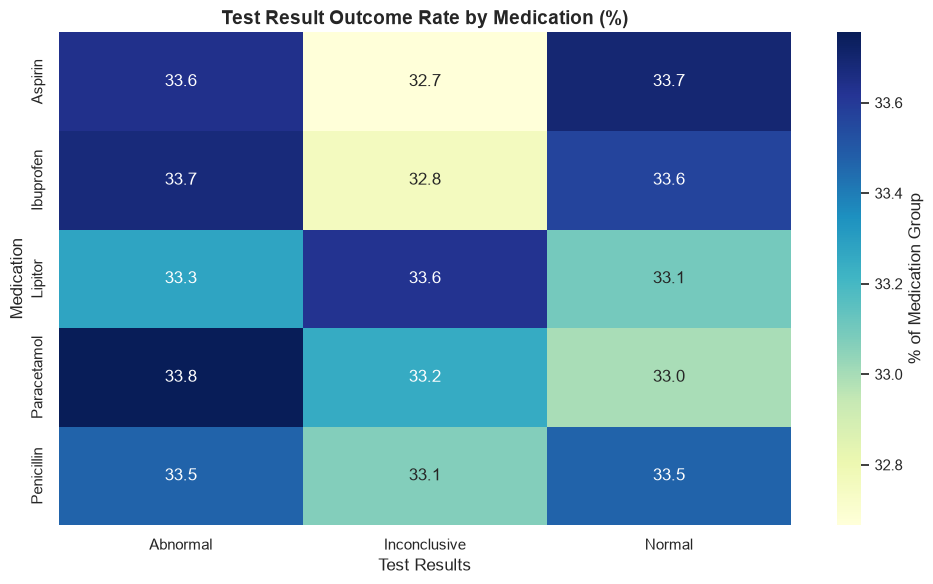

In [11]:
med_outcome = pd.crosstab(df['Medication'], df['Test Results'], normalize='index') * 100
print(med_outcome.round(1))

plt.figure(figsize=(10,6))
sns.heatmap(med_outcome, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% of Medication Group'})
plt.title('Test Result Outcome Rate by Medication (%)')
plt.xlabel('Test Results')
plt.ylabel('Medication')
plt.tight_layout()
plt.show()


**Observation:** Regardless of which of the 5 medications a patient received (Aspirin, Ibuprofen, Lipitor, Paracetamol, Penicillin), the split between Normal / Abnormal / Inconclusive test results stays within a couple of percentage points of 33% each — no medication is associated with a meaningfully higher "Normal" outcome rate than another.

**Business implication:** If this were real-world data, we would expect *some* medications to be more strongly associated with favorable outcomes for the conditions they treat. The flat pattern here means outcome-based medication effectiveness cannot currently be assessed from this dataset — a data-collection opportunity would be to link Medication and Test Results to the *specific condition being treated* and *treatment date*, rather than recording them as parallel, seemingly independent fields.


### 7.2 Blood type distribution is unrealistically uniform

C:\Users\sibyr\AppData\Local\Temp\ipykernel_12988\3735467771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=blood_pct.index, y=blood_pct.values, order=blood_pct.index, palette='flare')


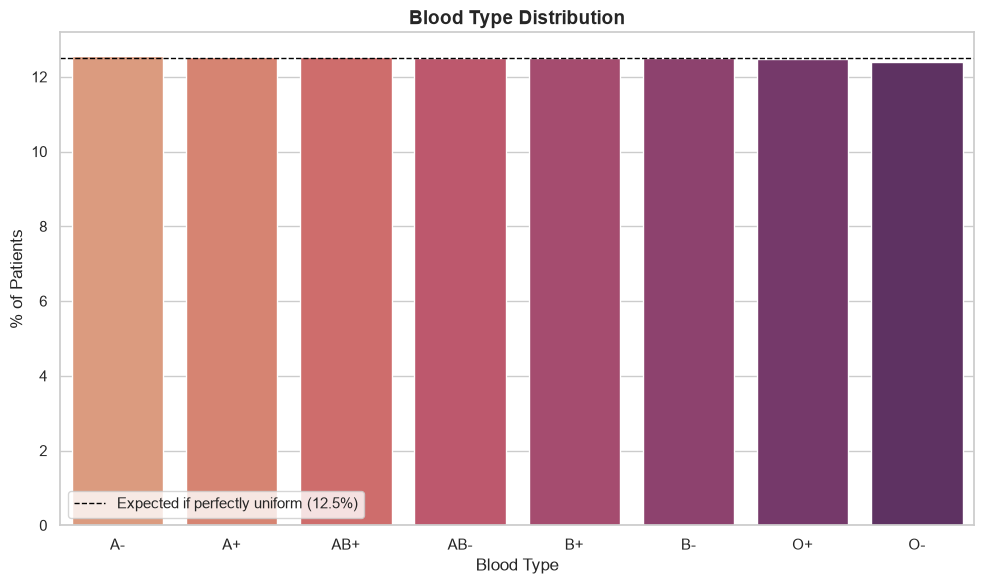

In [12]:
blood_pct = df['Blood Type'].value_counts(normalize=True) * 100
plt.figure(figsize=(10,6))
sns.barplot(x=blood_pct.index, y=blood_pct.values, order=blood_pct.index, palette='flare')
plt.title('Blood Type Distribution')
plt.ylabel('% of Patients')
plt.xlabel('Blood Type')
plt.axhline(12.5, color='black', linestyle='--', linewidth=1, label='Expected if perfectly uniform (12.5%)')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** All 8 blood types are represented at almost exactly 12.5% each (the dashed reference line), with a real-world population instead skewing heavily toward O+ and A+ (which together typically account for well over half of most populations).

**Business implication:** A uniform blood-type distribution is a strong marker of synthetic/simulated data rather than a real patient population. For any use case involving blood-supply planning or transfusion-demand forecasting, this field should not be trusted at face value — real regional blood-type frequency data should be substituted.


## 8. Potential Opportunities

Despite the data-quality caveats above, the analysis points to concrete, actionable next steps:

1. **Fix and re-baseline the Billing Amount field.** Remove or correctly classify the 108 negative-value records (Section 5.1), then re-run cost-driver analysis once cleaned — this is a quick win before any financial reporting is trusted.
2. **Enrich clinical detail to unlock cost modeling.** Since none of the existing categorical fields explain billing variation (Section 4.1), the highest-value data investment is adding procedure codes, severity/acuity scores, or itemized charges — this alone could turn an unpredictable cost field into an actionable pricing/forecasting model.
3. **Introduce a unique patient identifier.** This single change would unlock readmission tracking, patient-lifetime-value analysis, and chronic-condition monitoring (Section 5.3) — currently the single biggest blocker to patient-centric analytics.
4. **Standardize the Hospital field.** Cleaning or replacing the ~40,000 fragmented hospital-name values (Section 5.2) would enable facility-level benchmarking and vendor management, both high-value healthcare operations use cases that are currently unavailable.
5. **Validate against real seasonal and demographic patterns.** Since the current data shows no seasonality (Section 3.2) and an implausibly even age/blood-type/condition mix (Sections 2.1, 2.2, 7.2), any business plans (staffing, blood supply, marketing) should be cross-checked against external, real-world healthcare benchmarks rather than built on this dataset alone.
